In [10]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add project root to path
sys.path.append(str(Path("..").resolve()))

from constants import ASSETS_FOLDER

# Load trained models with different seeds


In [11]:
from constants import PROCESSED_DATA_FOLDER
from helpers import ModelData, get_model_performance, load_fitted_model


n_models = 24
k = 0

results_list = []

for seed in [42, 43, 123, None]:
    model_data = ModelData.from_pickle(
        PROCESSED_DATA_FOLDER / f"processed_data_{seed if seed else 'original'}.pkl"
    )
    eval_indices = model_data.eval_indices
    calibration_indices = model_data.calibration_indices

    for model_name in ["hmm", "vdhmm"]:
        for S in [2, 3, 4]:
            k += 1
            print(
                f"Processing {k}/{n_models}: {model_name} with {S} states (seed={seed})..."
            )
            # get processed data for given seed

            # Load the fitted model with the given seed
            try:
                model = load_fitted_model(model_name, S, seed=seed)
            except FileNotFoundError:
                print(
                    f"FileNotFound: {model_name} with {S} states and seed {seed} was not found! Skipping..."
                )
                continue

            close_prob = model.fit.stan_variable("close_prob")
            close_prob_mean = close_prob.mean(axis=0)
            # # Berechne AUC für Trainingsdaten (in Prozent)
            y_true = np.array(model.stan_data["Closed"])

            # Performance auf Eval-Daten mit get_model_performance
            perf_dict = get_model_performance(
                y_prob=close_prob_mean,
                y_exp=y_true,
                calibration_indices=calibration_indices,
                eval_indices=eval_indices,
                train_indices=np.arange(500),
            )

            # Use the already stored summary DataFrame (model.summary)
            # Calculate mean and std of R_hat across all parameters
            r_hat_mean = np.nanmean(model.summary["R_hat"])
            r_hat_std = np.nanstd(model.summary["R_hat"])

            results_list.append(
                {
                    "Model_Type": model_name.upper(),
                    "States": S,
                    "Seed": seed if seed else "Original",
                    "AUC_TRAIN": perf_dict["in_sample_auc"],
                    "AUC_TEST": perf_dict["auc"],
                    "R_HAT_MEAN": r_hat_mean,
                    "R_HAT_STD": r_hat_std,
                }
            )


print("\nResults:\n")
results_df = pd.DataFrame(results_list)

# Round results
results_df["AUC_TRAIN"] = results_df["AUC_TRAIN"].round(2)
results_df["AUC_TEST"] = results_df["AUC_TEST"].round(2)
results_df["R_HAT_MEAN"] = results_df["R_HAT_MEAN"].round(4)
results_df["R_HAT_STD"] = results_df["R_HAT_STD"].round(4)


results_df

Processing 1/24: hmm with 2 states (seed=42)...
Processing 2/24: hmm with 3 states (seed=42)...
Processing 3/24: hmm with 4 states (seed=42)...
Processing 4/24: vdhmm with 2 states (seed=42)...
Processing 5/24: vdhmm with 3 states (seed=42)...
Processing 6/24: vdhmm with 4 states (seed=42)...


Processing 7/24: hmm with 2 states (seed=43)...
Processing 8/24: hmm with 3 states (seed=43)...
Processing 9/24: hmm with 4 states (seed=43)...
Processing 10/24: vdhmm with 2 states (seed=43)...
Processing 11/24: vdhmm with 3 states (seed=43)...
Processing 12/24: vdhmm with 4 states (seed=43)...
Processing 13/24: hmm with 2 states (seed=123)...
Processing 14/24: hmm with 3 states (seed=123)...
Processing 15/24: hmm with 4 states (seed=123)...
Processing 16/24: vdhmm with 2 states (seed=123)...
Processing 17/24: vdhmm with 3 states (seed=123)...
Processing 18/24: vdhmm with 4 states (seed=123)...
Processing 19/24: hmm with 2 states (seed=None)...
Processing 20/24: hmm with 3 states (seed=None)...
Processing 21/24: hmm with 4 states (seed=None)...
Processing 22/24: vdhmm with 2 states (seed=None)...
Processing 23/24: vdhmm with 3 states (seed=None)...
Processing 24/24: vdhmm with 4 states (seed=None)...

Results:



,Model_Type,States,Seed,AUC_TRAIN,AUC_TEST,R_HAT_MEAN,R_HAT_STD
0,HMM,2,42,79.88,78.53,1.0036,0.0032
1,HMM,3,42,83.58,80.73,1.0019,0.0015
2,HMM,4,42,83.41,80.79,1.3089,0.2234
3,VDHMM,2,42,79.49,78.52,1.0008,0.0008
4,VDHMM,3,42,85.38,82.68,1.0058,0.0058
5,VDHMM,4,42,85.35,83.31,1.0021,0.0025
6,HMM,2,43,82.25,73.58,1.0007,0.0009
7,HMM,3,43,84.49,78.92,1.0011,0.0010
8,HMM,4,43,85.50,79.40,1.1365,0.2112
9,VDHMM,2,43,82.79,71.25,1.0361,0.0355


In [12]:
# Split results for different seeds
grouped_dfs = {}

for seed, group_df in results_df.groupby("Seed"):
    grouped_dfs[seed] = group_df.copy()

print("\n" + "=" * 60)
print("SEED 42:")
print(60 * "=")
display(grouped_dfs[42])


print("\n" + "=" * 60)
print("SEED 43:")
print(60 * "=")
display(grouped_dfs[43])


print("\n" + "=" * 60)
print("SEED 123:")
print(60 * "=")
display(grouped_dfs[123])

print("\n" + "=" * 60)
print("ORIGINAL INDICES")
print(60 * "=")
display(grouped_dfs["Original"])


SEED 42:


,Model_Type,States,Seed,AUC_TRAIN,AUC_TEST,R_HAT_MEAN,R_HAT_STD
0,HMM,2,42,79.88,78.53,1.0036,0.0032
1,HMM,3,42,83.58,80.73,1.0019,0.0015
2,HMM,4,42,83.41,80.79,1.3089,0.2234
3,VDHMM,2,42,79.49,78.52,1.0008,0.0008
4,VDHMM,3,42,85.38,82.68,1.0058,0.0058
5,VDHMM,4,42,85.35,83.31,1.0021,0.0025



SEED 43:


,Model_Type,States,Seed,AUC_TRAIN,AUC_TEST,R_HAT_MEAN,R_HAT_STD
6,HMM,2,43,82.25,73.58,1.0007,0.0009
7,HMM,3,43,84.49,78.92,1.0011,0.0010
8,HMM,4,43,85.50,79.40,1.1365,0.2112
9,VDHMM,2,43,82.79,71.25,1.0361,0.0355
10,VDHMM,3,43,86.15,81.20,1.0006,0.0007
11,VDHMM,4,43,86.83,80.63,1.0007,0.0007



SEED 123:


,Model_Type,States,Seed,AUC_TRAIN,AUC_TEST,R_HAT_MEAN,R_HAT_STD
12,HMM,2,123,78.60,77.52,1.0010,0.0007
13,HMM,3,123,82.51,81.64,1.0008,0.0007
14,HMM,4,123,82.92,82.82,1.1322,0.2121
15,VDHMM,2,123,78.19,77.61,1.0007,0.0008
16,VDHMM,3,123,84.41,83.59,1.0009,0.0008
17,VDHMM,4,123,83.94,83.98,1.0009,0.0010



ORIGINAL INDICES


,Model_Type,States,Seed,AUC_TRAIN,AUC_TEST,R_HAT_MEAN,R_HAT_STD
18,HMM,2,Original,78.49,77.27,1.0010,0.0011
19,HMM,3,Original,81.83,82.67,1.0418,0.0418
20,HMM,4,Original,82.45,83.62,1.0007,0.0011
21,VDHMM,2,Original,78.46,76.84,1.0012,0.0014
22,VDHMM,3,Original,83.92,84.40,1.0008,0.0012
23,VDHMM,4,Original,83.24,84.77,1.0014,0.0017


# Robustness Analysis: Seed Variability

---

## Statistische Analyse der Model-Robustheit

Analyse der Performance-Stabilität der HMM und VDHMM Modelle über verschiedene Seeds hinweg


In [13]:
print("=" * 110)
print("HMM ROBUSTNESS DATA (All Seeds: 42, 43, 123)")
print("=" * 110)

# Filter all models out, that have a Mean R_hat above 1.01
results_df = results_df[results_df["R_HAT_MEAN"] < 1.01]


# Berechne Statistiken pro Modellkonfiguration
robustness_stats = (
    results_df.groupby(["Model_Type", "States"])
    .agg(
        {
            "AUC_TEST": ["mean", "std", "min", "max"],
            "AUC_TRAIN": ["mean", "std"],
            "R_HAT_MEAN": ["mean", "max"],
        }
    )
    .round(2)
)

# Flatten multi-level columns
robustness_stats.columns = [
    "_".join(col).strip() for col in robustness_stats.columns.values
]
robustness_stats = robustness_stats.reset_index()

# Berechne Coefficient of Variation (CV) für AUC_TEST in Prozent
robustness_stats["AUC_TEST_CV_%"] = (
    robustness_stats["AUC_TEST_std"] / robustness_stats["AUC_TEST_mean"] * 100
).round(2)

# Berechne Range für AUC_TEST
robustness_stats["AUC_TEST_Range"] = (
    robustness_stats["AUC_TEST_max"] - robustness_stats["AUC_TEST_min"]
).round(2)

print("\n" + "=" * 110)
print("ROBUSTNESS STATISTICS: Mean ± Std across Seeds")
print("=" * 110)
print(robustness_stats.to_string(index=False))

# Identifiziere die robustesten Modelle (niedrigster CV%)
print("\n" + "=" * 110)
print("ROBUSTNESS RANKING (by Coefficient of Variation)")
print("=" * 110)
robustness_ranking = robustness_stats.sort_values("AUC_TEST_CV_%")
print(
    robustness_ranking[
        [
            "Model_Type",
            "States",
            "AUC_TEST_mean",
            "AUC_TEST_std",
            "AUC_TEST_CV_%",
            "AUC_TEST_Range",
        ]
    ].to_string(index=False)
)

HMM ROBUSTNESS DATA (All Seeds: 42, 43, 123)

ROBUSTNESS STATISTICS: Mean ± Std across Seeds
Model_Type  States  AUC_TEST_mean  AUC_TEST_std  AUC_TEST_min  AUC_TEST_max  AUC_TRAIN_mean  AUC_TRAIN_std  R_HAT_MEAN_mean  R_HAT_MEAN_max  AUC_TEST_CV_%  AUC_TEST_Range
       HMM       2          76.72          2.17         73.58         78.53           79.80           1.75              1.0            1.00           2.83            4.95
       HMM       3          80.43          1.38         78.92         81.64           83.53           0.99              1.0            1.00           1.72            2.72
       HMM       4          83.62           NaN         83.62         83.62           82.45            NaN              1.0            1.00            NaN            0.00
     VDHMM       2          77.66          0.84         76.84         78.52           78.71           0.69              1.0            1.00           1.08            1.68
     VDHMM       3          82.97          1.37     

## Visualisierung: Seed Variability


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setze Seaborn Style
sns.set_style("whitegrid")

### 2. Mean AUC Test with Standard Deviation (Error Bars)

**Interpretation:**

- Bars show the mean AUC across all seeds
- Error bars show the standard deviation
- Smaller error bars = higher robustness


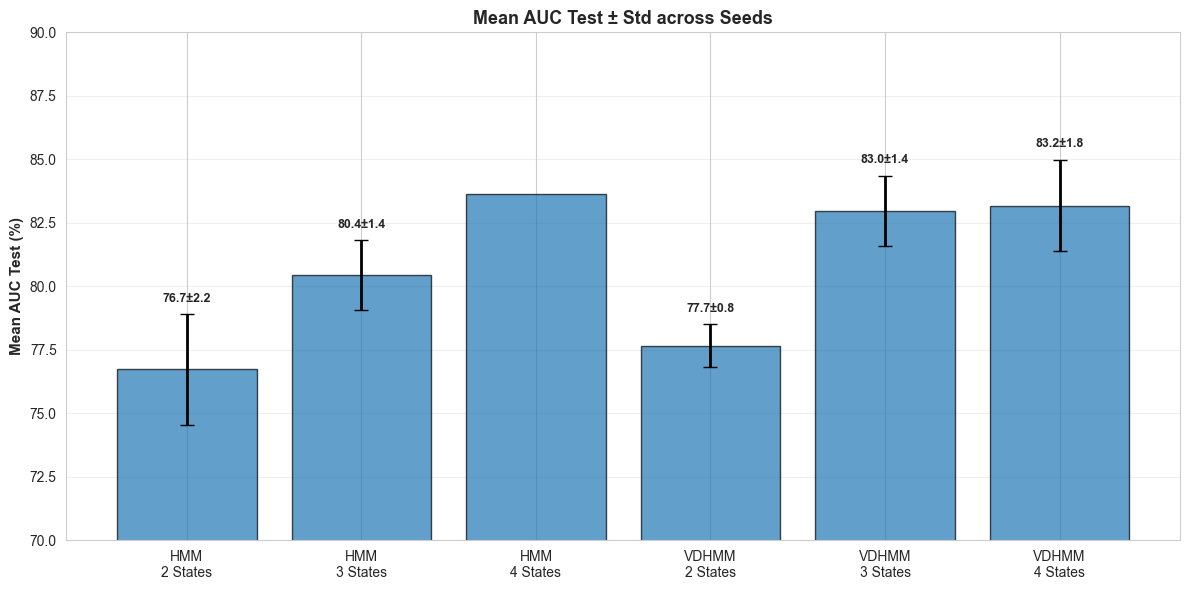

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

x_pos = np.arange(len(robustness_stats))

bars = ax.bar(
    x_pos,
    robustness_stats["AUC_TEST_mean"],
    yerr=robustness_stats["AUC_TEST_std"],
    alpha=0.7,
    edgecolor="black",
    capsize=5,
    error_kw={"linewidth": 2},
)

ax.set_ylabel("Mean AUC Test (%)", fontsize=11, fontweight="bold")
ax.set_title("Mean AUC Test ± Std across Seeds", fontsize=13, fontweight="bold")
ax.set_xticks(x_pos)
ax.set_xticklabels(
    [
        f"{row['Model_Type']}\n{row['States']} States"
        for _, row in robustness_stats.iterrows()
    ],
    fontsize=10,
)
ax.set_ylim([70, 90])
ax.grid(axis="y", alpha=0.3)

# Values above bars
for i, (mean, std) in enumerate(
    zip(robustness_stats["AUC_TEST_mean"], robustness_stats["AUC_TEST_std"])
):
    ax.text(
        i,
        mean + std + 0.5,
        f"{mean:.1f}±{std:.1f}",
        ha="center",
        fontsize=9,
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig(
    ASSETS_FOLDER / "robustness_mean_auc.png",
    dpi=300,
    bbox_inches="tight",
    transparent=False,
)
plt.show()

### 3. Coefficient of Variation (CV%) - Robustness Ranking

**Interpretation:**

- Coefficient of Variation (CV%) = Standard Deviation / Mean × 100
- Lower CV% = more robust model (less relative variability)
- CV% < 3% is considered very robust (which would mean a difference of ±2.5%)


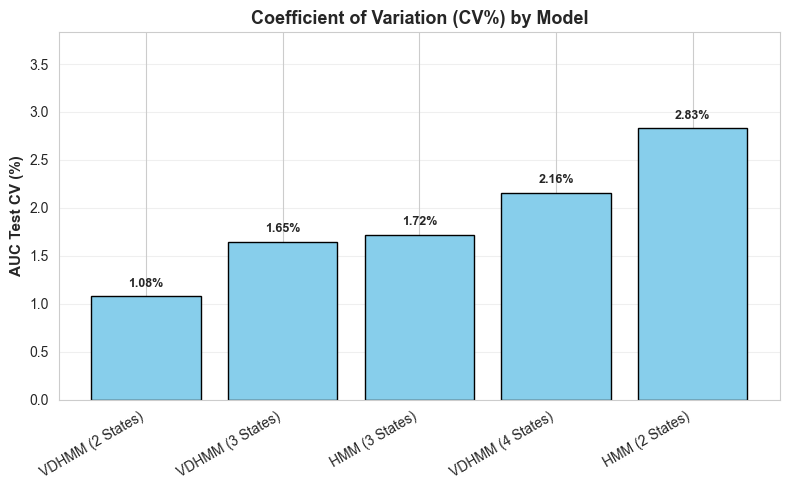

,Model_Type,States,AUC_TEST_mean,AUC_TEST_std,AUC_TEST_min,AUC_TEST_max,AUC_TRAIN_mean,AUC_TRAIN_std,R_HAT_MEAN_mean,R_HAT_MEAN_max,AUC_TEST_CV_%,AUC_TEST_Range
3,VDHMM,2,77.66,0.84,76.84,78.52,78.71,0.69,1.0,1.00,1.08,1.68
4,VDHMM,3,82.97,1.37,81.20,84.40,84.96,1.00,1.0,1.01,1.65,3.20
1,HMM,3,80.43,1.38,78.92,81.64,83.53,0.99,1.0,1.00,1.72,2.72
5,VDHMM,4,83.17,1.80,80.63,84.77,84.84,1.59,1.0,1.00,2.16,4.14
0,HMM,2,76.72,2.17,73.58,78.53,79.80,1.75,1.0,1.00,2.83,4.95
2,HMM,4,83.62,NaN,83.62,83.62,82.45,NaN,1.0,1.00,NaN,0.00


In [16]:
cv_sorted = robustness_stats.sort_values("AUC_TEST_CV_%")

plt.figure(figsize=(8, 5))
bars = plt.bar(
    x=[
        f"{row['Model_Type']} ({row['States']} States)"
        for _, row in cv_sorted.iterrows()
    ],
    height=cv_sorted["AUC_TEST_CV_%"],
    color="skyblue",
    edgecolor="black",
)

plt.ylabel("AUC Test CV (%)", fontsize=11, fontweight="bold")
plt.title("Coefficient of Variation (CV%) by Model", fontsize=13, fontweight="bold")
plt.xticks(rotation=30, ha="right", fontsize=10)
plt.ylim(0, cv_sorted["AUC_TEST_CV_%"].max() + 1)
plt.grid(axis="y", alpha=0.3)

# Add value labels above bars
for bar, value in zip(bars, cv_sorted["AUC_TEST_CV_%"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.07,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig(
    ASSETS_FOLDER / "robustness_cv_percentage.png",
    dpi=300,
    bbox_inches="tight",
    transparent=False,
)
plt.show()
cv_sorted

### 4. Heatmap: Model × Seed Performance Matrix

**Interpretation:**

- Green cells = high performance, yellow = medium, red = low performance
- Consistent colors across seeds = robust models
- VDHMM (3/4 States) shows consistently green values (>80% AUC)
- HMM (2 States) with Seed 43 and VDHMM (2 States) with Seed 43 show weaknesses (~72-74% AUC)


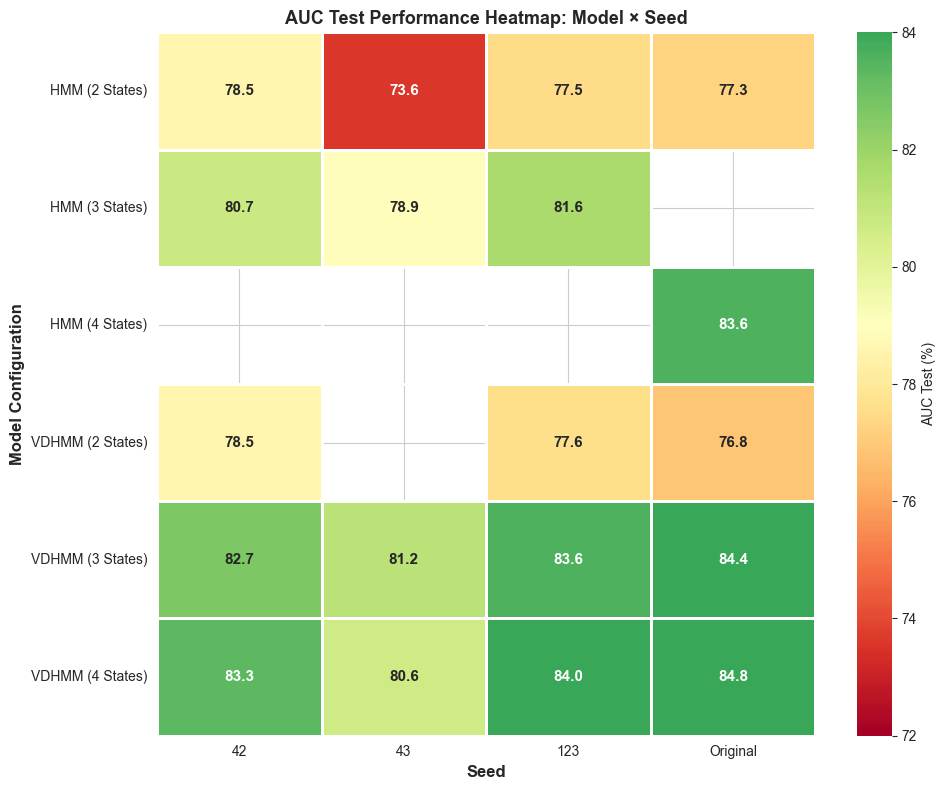

In [17]:
fig, ax = plt.subplots(figsize=(10, 8))

# Pivot table for heatmap
pivot_data = results_df.pivot_table(
    values="AUC_TEST", index=["Model_Type", "States"], columns="Seed"
)

# Create labels
row_labels = [f"{mt} ({s} States)" for mt, s in pivot_data.index]

sns.heatmap(
    pivot_data,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    center=79,
    vmin=72,
    vmax=84,
    cbar_kws={"label": "AUC Test (%)"},
    yticklabels=row_labels,
    ax=ax,
    linewidths=1,
    annot_kws={"fontsize": 11, "fontweight": "bold"},
)

ax.set_xlabel("Seed", fontsize=12, fontweight="bold")
ax.set_ylabel("Model Configuration", fontsize=12, fontweight="bold")
ax.set_title(
    "AUC Test Performance Heatmap: Model × Seed", fontsize=13, fontweight="bold"
)

plt.tight_layout()
plt.savefig(
    ASSETS_FOLDER / "robustness_seed_matrix.png",
    dpi=300,
    bbox_inches="tight",
    transparent=False,
)
plt.show()

In [18]:
# Robustness summary
print("=" * 100)
print("ROBUSTNESS SUMMARY: Top 3 Most Robust Models")
print("=" * 100)

top3_robust = robustness_ranking.head(3)

for i, (idx, row) in enumerate(top3_robust.iterrows(), 1):
    print(f"\n{i}. {row['Model_Type']} ({row['States']} States)")
    print(f"   - Mean AUC Test: {row['AUC_TEST_mean']:.2f}%")
    print(f"   - Std: ±{row['AUC_TEST_std']:.2f}%")
    print(f"   - Coefficient of Variation (CV): {row['AUC_TEST_CV_%']:.2f}%")
    print(
        f"   - Range: {row['AUC_TEST_Range']:.2f}% (Min: {row['AUC_TEST_min']:.2f}%, Max: {row['AUC_TEST_max']:.2f}%)"
    )
    print(
        f"   - Mean R-hat: {row['R_HAT_MEAN_mean']:.4f} (Max: {row['R_HAT_MEAN_max']:.4f})"
    )

ROBUSTNESS SUMMARY: Top 3 Most Robust Models

1. VDHMM (2 States)
   - Mean AUC Test: 77.66%
   - Std: ±0.84%
   - Coefficient of Variation (CV): 1.08%
   - Range: 1.68% (Min: 76.84%, Max: 78.52%)
   - Mean R-hat: 1.0000 (Max: 1.0000)

2. VDHMM (3 States)
   - Mean AUC Test: 82.97%
   - Std: ±1.37%
   - Coefficient of Variation (CV): 1.65%
   - Range: 3.20% (Min: 81.20%, Max: 84.40%)
   - Mean R-hat: 1.0000 (Max: 1.0100)

3. HMM (3 States)
   - Mean AUC Test: 80.43%
   - Std: ±1.38%
   - Coefficient of Variation (CV): 1.72%
   - Range: 2.72% (Min: 78.92%, Max: 81.64%)
   - Mean R-hat: 1.0000 (Max: 1.0000)
